<h1><center>Machine Learning Project - AVAZU<center></h1>


In [2]:
import sys
from zipfile import ZipFile
import os.path as op
try:
    from urllib.request import urlretrieve
except ImportError:  # Python 2 compat
    from urllib import urlretrieve
    
AVAZU_URL = "https://bianchi.wp.imt.fr/files/2019/05/train-1000000.zip"
AVAZU_FILENAME = AVAZU_URL.rsplit('/', 1)[1]


if not op.exists(AVAZU_FILENAME):
    print('Downloading %s to %s...' % (AVAZU_URL, AVAZU_FILENAME))
    urlretrieve(AVAZU_URL, AVAZU_FILENAME)
    ZipFile(AVAZU_FILENAME).extractall('.')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
%matplotlib inline

Data description here: https://www.kaggle.com/c/avazu-ctr-prediction/data  


In [4]:
df = pd.read_csv('train-1000000')

## Work assignment

1.   Perform Exploratory Data Analysis (EDA)
2.   Predict the probability that an add is clicked, based on the features. 
3.   Evaluate the performance of your method.

## Work evaluation

Your work will be evaluated based on:

*   The interest of the EDA (4 points)
*   The quality of the comments/remarks throughout the notebook (4 points)
*   The feature engineering (5 points)
*   The efforts made in trying several predictors and tuning them (5 points)
*   The relevance of the performance criteria used to conclude (2 points)
*   BONUS (+1pt) : Register to the AVAZU challenge in Kaggle. What is your rank?

You may find the following script useful to convert the raw time stamp into a more useable feature. For instance, you may generate new pandas series using the code:

```
df['hour'].apply(lambda x:datesplit(x).weekday())
df['hour'].apply(lambda x:datesplit(x).hour)
```



In [5]:
import datetime
def datesplit(originalDate):
    originalDate = str(originalDate)
    
    year = int("20" + originalDate[0:2])
    month = int(originalDate[2:4])
    day = int(originalDate[4:6])
    hour = int(originalDate[6:8])
    
    return datetime.datetime(year, month, day, hour)

# Exemple :
datesplit(14102915).weekday(), datesplit(14102915).hour

(2, 15)

# my work

## 1. EDA

In [6]:
# First examine the shape and the first few rows of the dataset
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1000000, 24)


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,3.983206e+18,0,14102915,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,...,1,2,4687,320,50,423,2,39,100148,32
1,7.756884e+18,0,14103007,1002,0,cb809abf,74acf31a,50e219e0,ecad2386,7801e8d9,...,0,0,17894,320,50,2039,2,39,100077,32
2,6.941774e+17,0,14102711,1005,0,85f751fd,c4e18dd6,50e219e0,e9739828,df32afa9,...,1,0,22684,320,50,2619,1,163,100055,71
3,2.664154e+18,1,14102903,1005,0,85f751fd,c4e18dd6,50e219e0,a5184c22,b8d325c3,...,1,0,23222,320,50,2676,0,35,100176,221
4,1.480510e+19,0,14102902,1005,1,791b5571,fd13bc73,f028772b,ecad2386,7801e8d9,...,1,0,8330,320,50,761,3,175,100081,23


In [7]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Basic information about the dataset
print("\nDataset info:")
df.info()

# Basic statistics
print("\nBasic statistics:")
df.describe()

Missing values per column:
id                  0
click               0
hour                0
C1                  0
banner_pos          0
site_id             0
site_domain         0
site_category       0
app_id              0
app_domain          0
app_category        0
device_id           0
device_ip           0
device_model        0
device_type         0
device_conn_type    0
C14                 0
C15                 0
C16                 0
C17                 0
C18                 0
C19                 0
C20                 0
C21                 0
dtype: int64

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   id                1000000 non-null  float64
 1   click             1000000 non-null  int64  
 2   hour              1000000 non-null  int64  
 3   C1                1000000 non-null  int64  
 4   banner

,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
count,1.000000e+06,1000000.000000,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,9.226511e+18,0.169971,1.410256e+07,1004.968549,0.288466,1.015506,0.332436,18835.759473,318.888112,60.030918,2111.794488,1.432802,226.940103,53163.356361,83.404070
std,5.322835e+18,0.375608,2.966148e+02,1.096112,0.505974,0.527867,0.856103,4966.228494,21.279475,47.174174,610.393836,1.325815,350.944666,49960.216178,70.326773
min,1.003272e+13,0.000000,1.410210e+07,1001.000000,0.000000,0.000000,0.000000,375.000000,120.000000,20.000000,112.000000,0.000000,33.000000,-1.000000,1.000000
25%,4.613978e+18,0.000000,1.410230e+07,1005.000000,0.000000,1.000000,0.000000,16920.000000,320.000000,50.000000,1863.000000,0.000000,35.000000,-1.000000,23.000000
50%,9.238351e+18,0.000000,1.410260e+07,1005.000000,0.000000,1.000000,0.000000,20346.000000,320.000000,50.000000,2323.000000,2.000000,39.000000,100048.000000,61.000000
75%,1.384023e+19,0.000000,1.410281e+07,1005.000000,1.000000,1.000000,0.000000,21894.000000,320.000000,50.000000,2526.000000,3.000000,171.000000,100088.000000,101.000000
max,1.844670e+19,1.000000,1.410302e+07,1012.000000,7.000000,5.000000,5.000000,24043.000000,1024.000000,1024.000000,2757.000000,3.000000,1839.000000,100248.000000,255.000000


Click distribution (%):
click
0    83.0029
1    16.9971
Name: proportion, dtype: float64


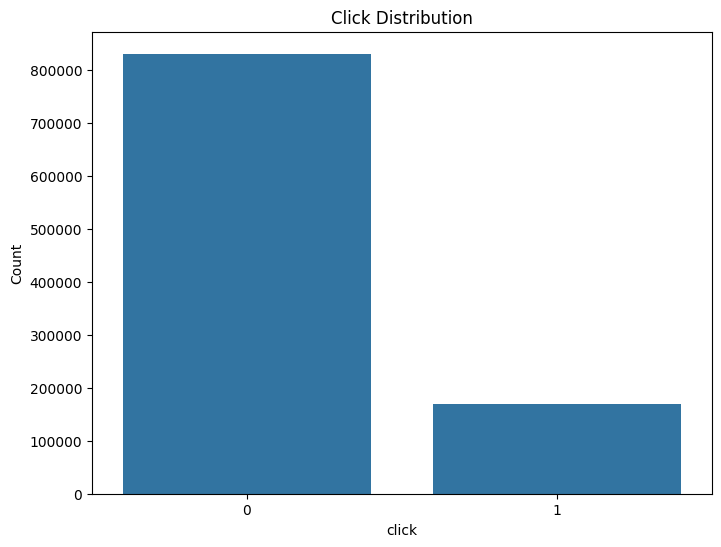

In [8]:
# Check the target variable distribution (click)
click_distribution = df['click'].value_counts(normalize=True) * 100
print(f"Click distribution (%):\n{click_distribution}")

# Visualize the class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='click', data=df)
plt.title('Click Distribution')
plt.ylabel('Count')
plt.show()


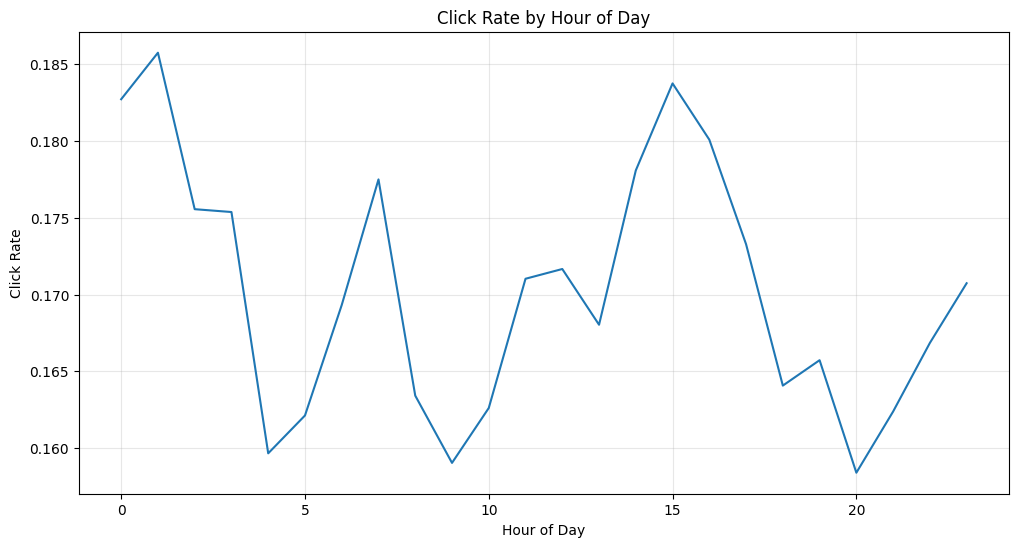

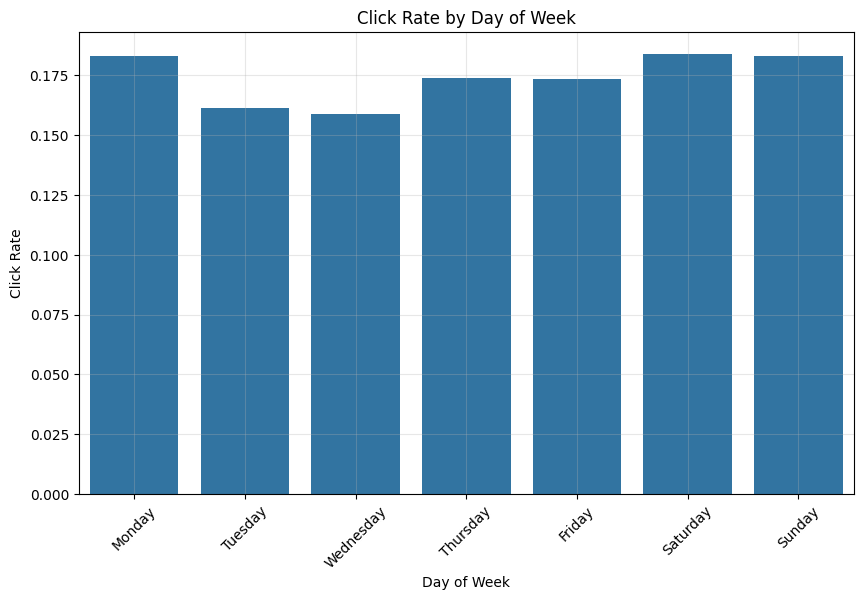

In [9]:
# extract temporal features from the hour column and analyze time patterns:

# Convert hour to datetime features
df['datetime'] = df['hour'].apply(datesplit)
df['weekday'] = df['hour'].apply(lambda x: datesplit(x).weekday())
df['hour_of_day'] = df['hour'].apply(lambda x: datesplit(x).hour)
df['day'] = df['hour'].apply(lambda x: datesplit(x).day)
df['month'] = df['hour'].apply(lambda x: datesplit(x).month)

# Visualize click rate by hour of day
plt.figure(figsize=(12, 6))
hour_click_rate = df.groupby('hour_of_day')['click'].mean()
sns.lineplot(x=hour_click_rate.index, y=hour_click_rate.values)
plt.title('Click Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Click Rate')
plt.grid(True, alpha=0.3)
plt.show()

# Visualize click rate by day of week
plt.figure(figsize=(10, 6))
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_click_rate = df.groupby('weekday')['click'].mean()
sns.barplot(x=weekday_click_rate.index, y=weekday_click_rate.values)
plt.xticks(ticks=range(7), labels=day_names, rotation=45)
plt.title('Click Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Click Rate')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# examine the categorical features and their relationship with clicks

# Identify categorical columns
cat_columns = df.select_dtypes(include=['object']).columns.tolist()
cat_columns += ['site_id', 'app_id', 'device_model', 'device_id', 'device_ip']
print(f"Categorical columns: {cat_columns}")

# For each categorical column, calculate the number of unique values
for col in cat_columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")


Categorical columns: ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip', 'device_model', 'site_id', 'app_id', 'device_model', 'device_id', 'device_ip']
site_id: 2651 unique values
site_domain: 2871 unique values
site_category: 22 unique values
app_id: 3157 unique values
app_domain: 198 unique values
app_category: 26 unique values
device_id: 150501 unique values
device_ip: 555248 unique values
device_model: 5168 unique values
site_id: 2651 unique values
app_id: 3157 unique values
device_model: 5168 unique values
device_id: 150501 unique values
device_ip: 555248 unique values


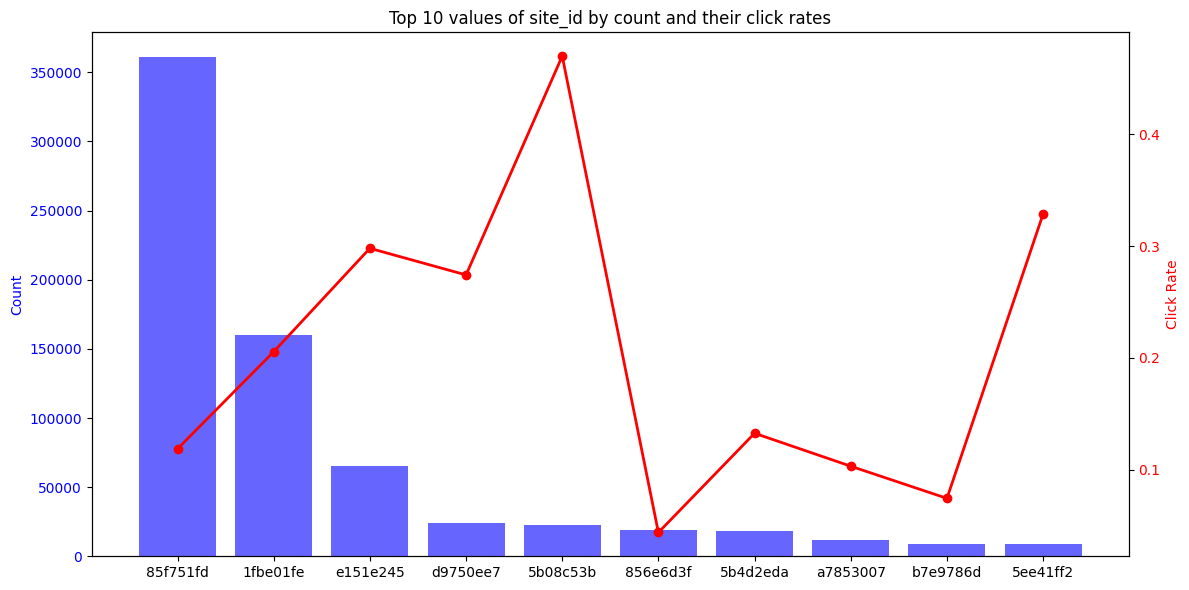

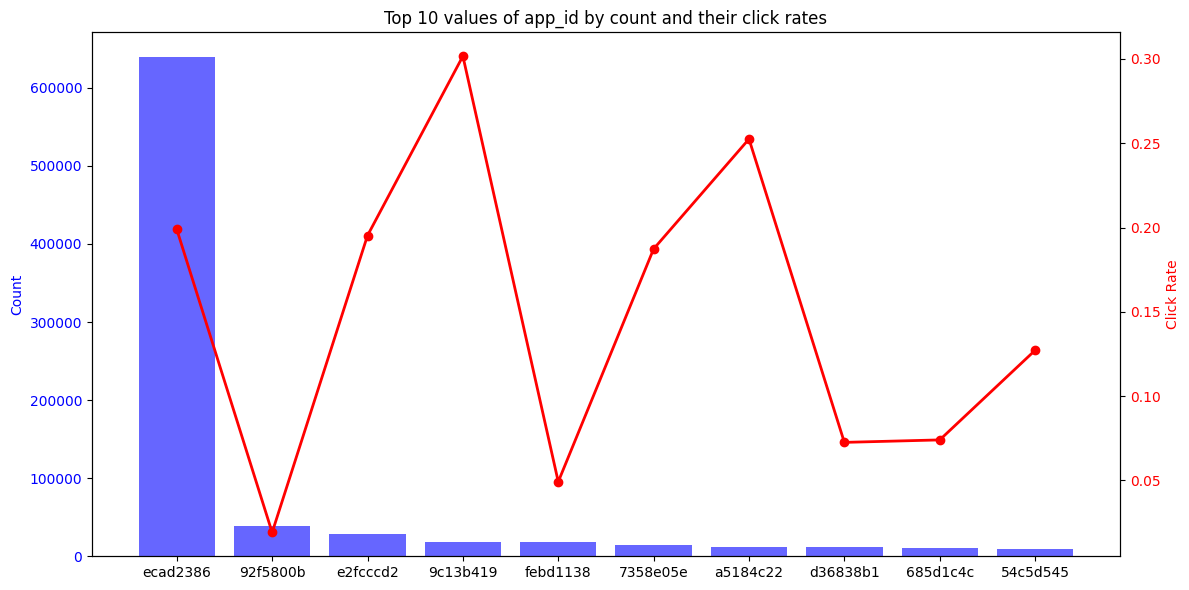

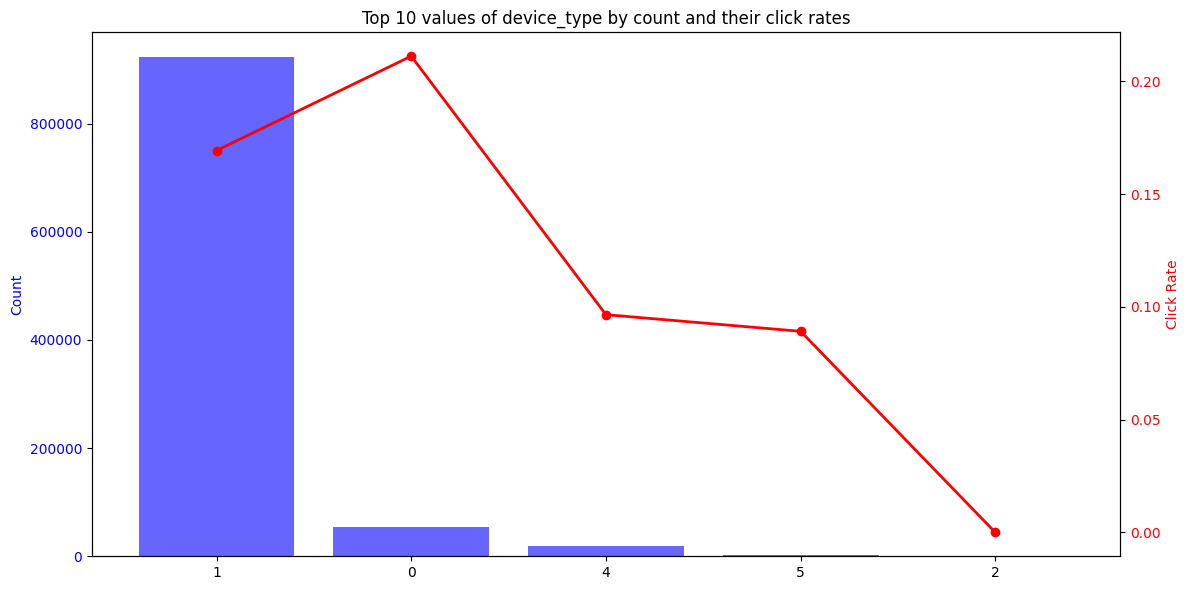

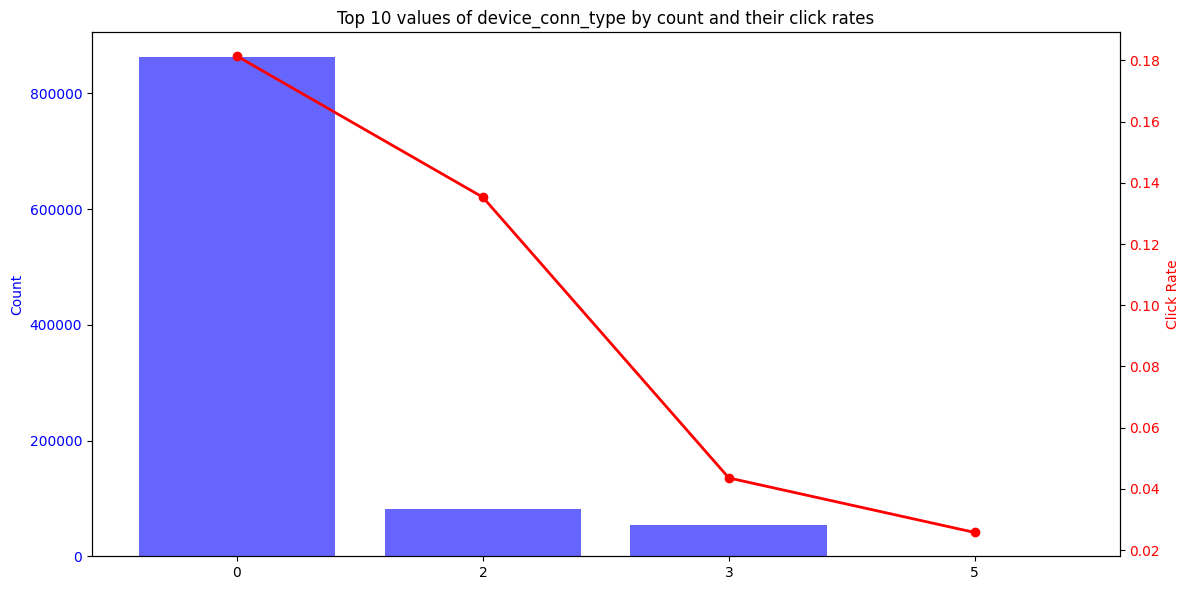

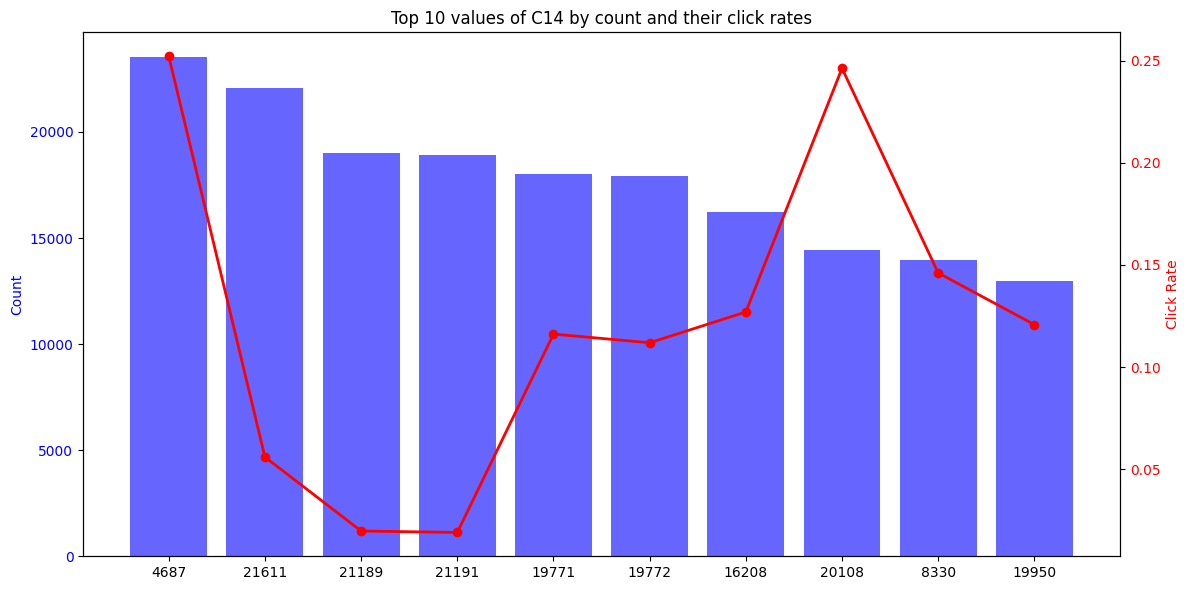

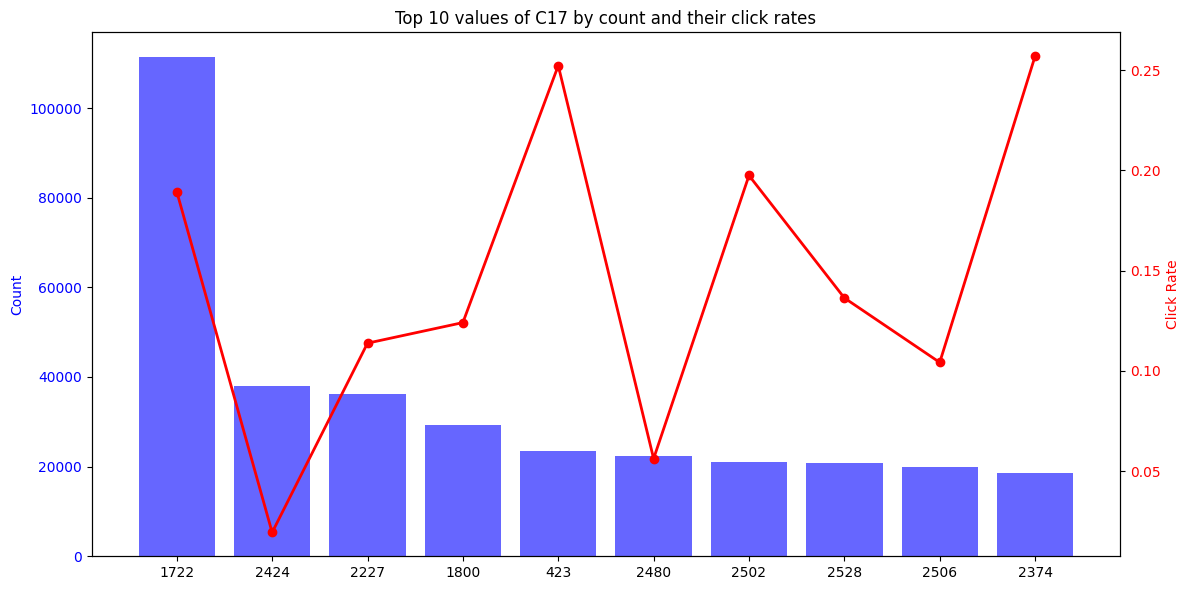

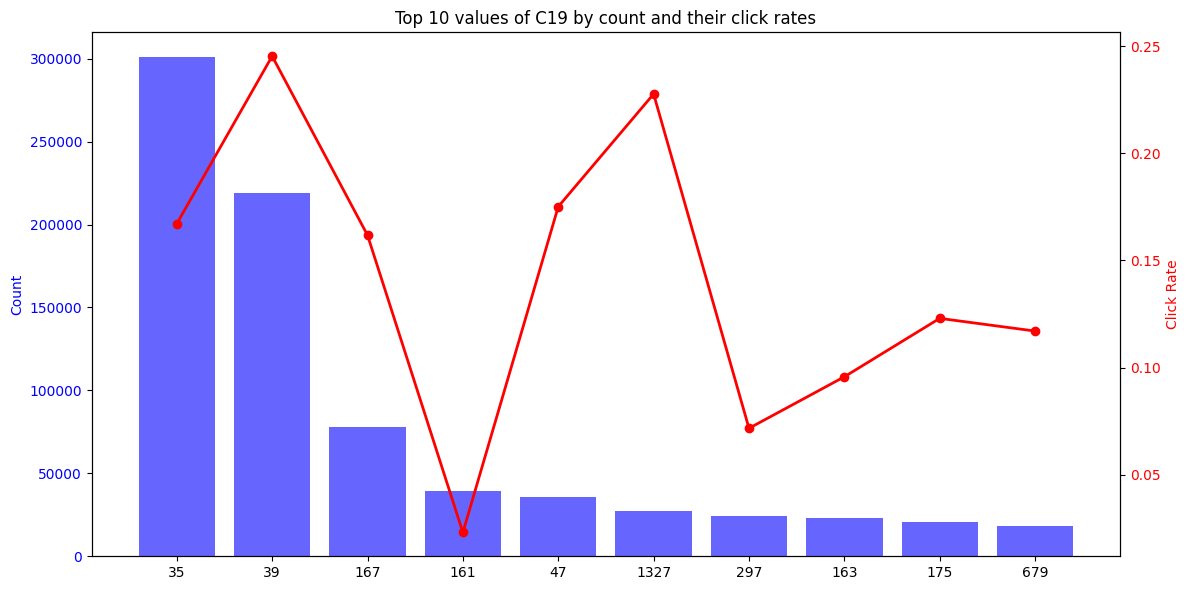

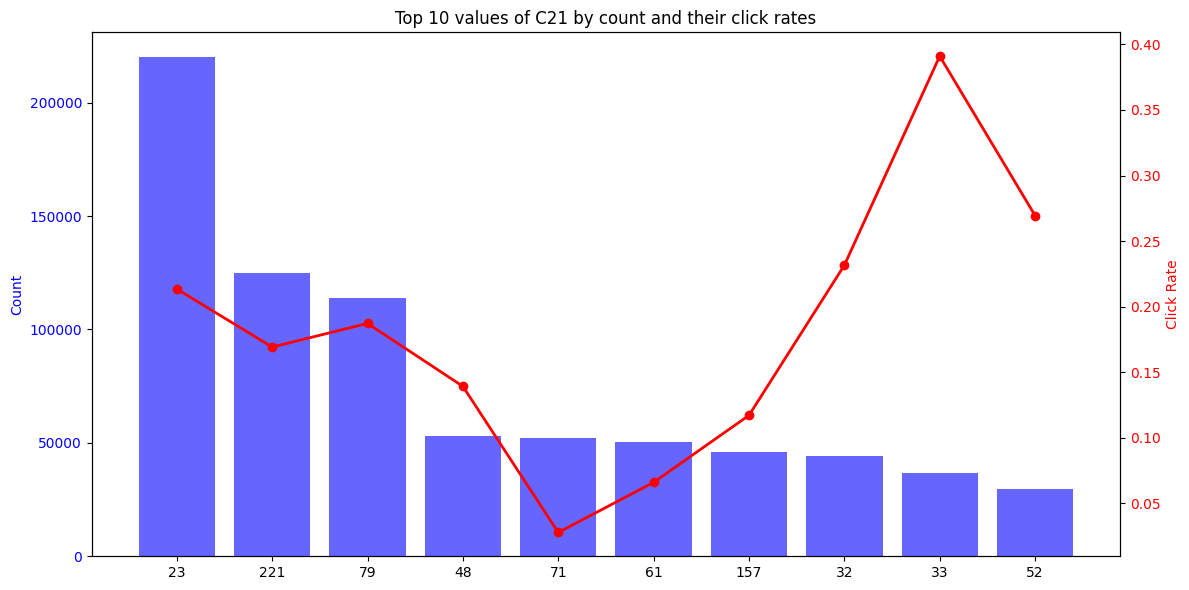

In [11]:
# Examine cardinality and click rates for key categorical features
important_cat_features = ['site_id', 'app_id', 'device_type', 'device_conn_type', 'C14', 'C17', 'C19', 'C21']

for feature in important_cat_features:
    # Get value counts
    value_counts = df[feature].value_counts().reset_index()
    value_counts.columns = [feature, 'count']
    
    # Get click rates per value
    click_rates = df.groupby(feature)['click'].mean().reset_index()
    click_rates.columns = [feature, 'click_rate']
    
    # Merge
    feature_analysis = pd.merge(value_counts, click_rates, on=feature)
    
    # Sort by count
    feature_analysis = feature_analysis.sort_values(by='count', ascending=False).head(10)
    
    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Bar plot for counts
    ax1.bar(feature_analysis[feature].astype(str), feature_analysis['count'], color='blue', alpha=0.6)
    ax1.set_ylabel('Count', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # Line plot for click rates
    ax2 = ax1.twinx()
    ax2.plot(feature_analysis[feature].astype(str), feature_analysis['click_rate'], 'ro-', linewidth=2)
    ax2.set_ylabel('Click Rate', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    plt.title(f'Top 10 values of {feature} by count and their click rates')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


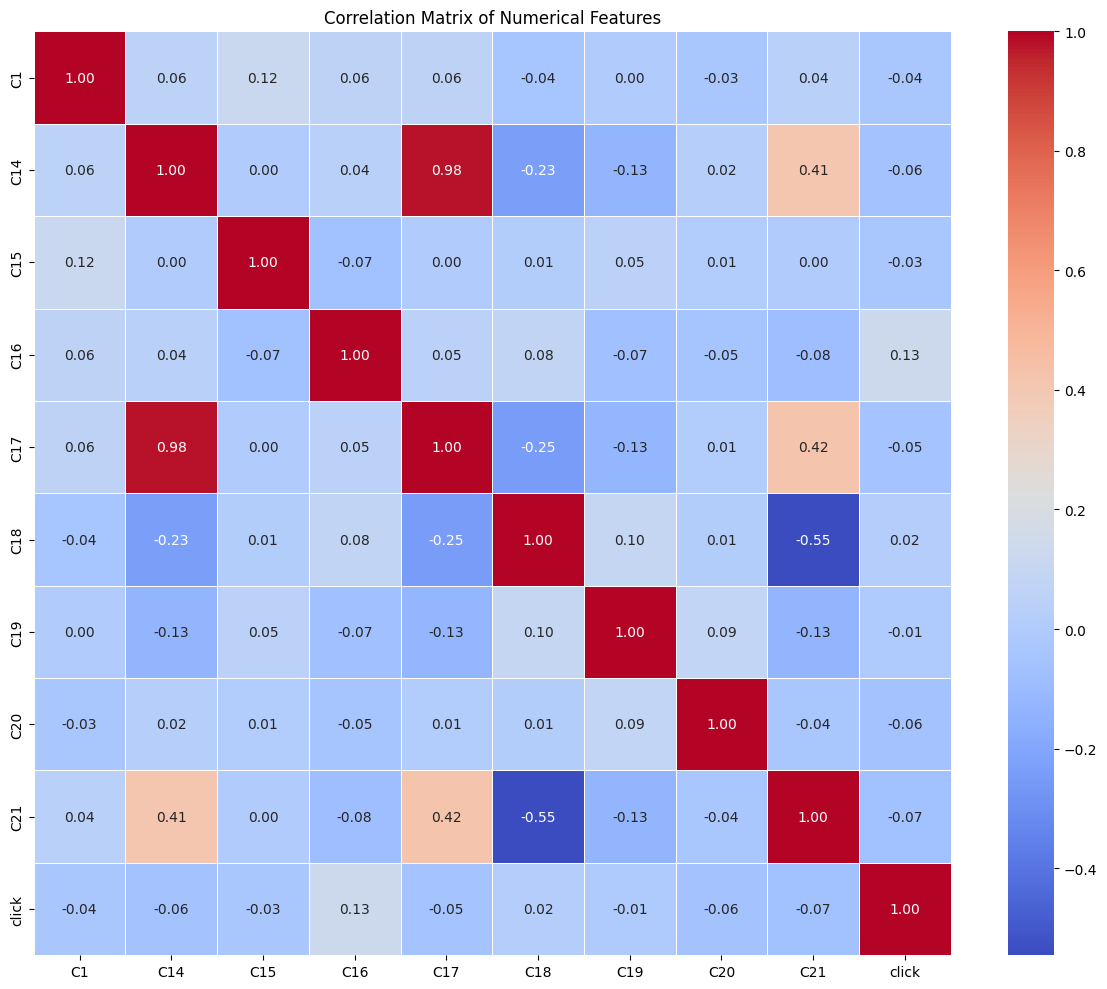

In [12]:
# correlations between numerical features

# Select numerical columns (C1 to C21 that are actually numerical)
num_columns = [col for col in df.columns if col.startswith('C') and df[col].dtype != 'object']

# Correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df[num_columns + ['click']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()


## 2. feature engineering

In [13]:
# Feature Engineering

# 1. Handle categorical features with high cardinality
high_card_features = ['site_id', 'app_id', 'device_model', 'device_id', 'device_ip']

# For high cardinality features, replace rare categories with 'Other'
for feature in high_card_features:
    # Get value counts
    value_counts = df[feature].value_counts()
    
    # Get the top 100 categories
    top_categories = value_counts.nlargest(100).index
    
    # Replace rare categories with 'Other'
    df[feature + '_processed'] = df[feature].apply(lambda x: x if x in top_categories else 'Other')

# 2. Create time-based features
# Hour of day is cyclic, so we can create sine and cosine features
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day']/24)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday']/7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday']/7)

# 3. Feature interaction
# Interact site/app features with device type
df['site_device'] = df['site_id_processed'].astype(str) + '_' + df['device_type'].astype(str)
df['app_device'] = df['app_id_processed'].astype(str) + '_' + df['device_type'].astype(str)

# 4. Aggregate features based on click behavior
# Create click rate encodings for important categorical features
click_rate_features = ['site_id_processed', 'app_id_processed', 'device_type', 'device_conn_type', 'C14', 'C17']

# Use cross-validation to avoid data leakage
from sklearn.model_selection import KFold

n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Initialize columns for target encoding
for feature in click_rate_features:
    df[feature + '_click_rate'] = np.nan

# Perform target encoding
for train_idx, valid_idx in kf.split(df):
    # For each fold
    for feature in click_rate_features:
        # Calculate mean click rate from training data
        mean_click_rates = df.iloc[train_idx].groupby(feature)['click'].mean()
        
        # Map to validation data
        df.loc[valid_idx, feature + '_click_rate'] = df.iloc[valid_idx][feature].map(mean_click_rates)
    
# Fill missing values for categories not seen in training
for feature in click_rate_features:
    # Fill with overall mean
    overall_mean = df['click'].mean()
    df[feature + '_click_rate'].fillna(overall_mean, inplace=True)


C:\Users\MacBook Air\AppData\Local\Temp\ipykernel_13940\3841635269.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[feature + '_click_rate'].fillna(overall_mean, inplace=True)


In [14]:
# Prepare data for modeling

# Select features to use
feature_columns = [
    # Processed categorical features
    'site_id_processed', 'app_id_processed', 'device_model_processed', 
    'device_type', 'device_conn_type',
    # Original C features 
    'C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
    # Time features
    'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
    # Click rate encodings
    'site_id_processed_click_rate', 'app_id_processed_click_rate', 
    'device_type_click_rate', 'device_conn_type_click_rate',
    'C14_click_rate', 'C17_click_rate'
]

# Handle categorical features
from sklearn.preprocessing import LabelEncoder

# Identify categorical features that need encoding
cat_features_to_encode = [
    'site_id_processed', 'app_id_processed', 'device_model_processed', 
    'device_type', 'device_conn_type'
]

# Apply label encoding
for feature in cat_features_to_encode:
    le = LabelEncoder()
    df[feature + '_encoded'] = le.fit_transform(df[feature].astype(str))
    # Update feature columns
    feature_columns.remove(feature)
    feature_columns.append(feature + '_encoded')

# Prepare X and y
X = df[feature_columns]
y = df['click']

# Check for missing values and handle them
print("Missing values in features:")
print(X.isnull().sum())

# Fill any missing values
X = X.fillna(-1)  # Fill with -1 as a special value

# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")


Missing values in features:
C1                                0
C14                               0
C15                               0
C16                               0
C17                               0
C18                               0
C19                               0
C20                               0
C21                               0
hour_sin                          0
hour_cos                          0
weekday_sin                       0
weekday_cos                       0
site_id_processed_click_rate      0
app_id_processed_click_rate       0
device_type_click_rate            0
device_conn_type_click_rate       0
C14_click_rate                    0
C17_click_rate                    0
site_id_processed_encoded         0
app_id_processed_encoded          0
device_model_processed_encoded    0
device_type_encoded               0
device_conn_type_encoded          0
dtype: int64
Training set shape: (800000, 24)
Test set shape: (200000, 24)


## Training

In [15]:
# Import necessary libraries
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import time

# Function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    start_time = time.time()
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions (probabilities)
    y_train_pred_proba = model.predict_proba(X_train)[:, 1]
    y_test_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    train_auc = roc_auc_score(y_train, y_train_pred_proba)
    test_auc = roc_auc_score(y_test, y_test_pred_proba)
    
    train_log_loss = log_loss(y_train, y_train_pred_proba)
    test_log_loss = log_loss(y_test, y_test_pred_proba)
    
    # Convert probabilities to binary predictions
    y_train_pred = (y_train_pred_proba > 0.5).astype(int)
    y_test_pred = (y_test_pred_proba > 0.5).astype(int)
    
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    # Print results
    training_time = time.time() - start_time
    print(f"Model: {model_name}")
    print(f"Training time: {training_time:.2f} seconds")
    print(f"Train AUC: {train_auc:.4f}, Test AUC: {test_auc:.4f}")
    print(f"Train Log Loss: {train_log_loss:.4f}, Test Log Loss: {test_log_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred))
    print("-" * 50)
    
    return {
        'model': model,
        'model_name': model_name,
        'train_auc': train_auc,
        'test_auc': test_auc,
        'train_log_loss': train_log_loss,
        'test_log_loss': test_log_loss,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'training_time': training_time
    }

# 1. Logistic Regression (baseline model)
lr_model = LogisticRegression(max_iter=100, C=0.1, solver='liblinear', random_state=42)
lr_results = evaluate_model(lr_model, X_train, X_test, y_train, y_test, "Logistic Regression")

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, 
                                  random_state=42, n_jobs=-1)
rf_results = evaluate_model(rf_model, X_train, X_test, y_train, y_test, "Random Forest")

# 3. Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                                      random_state=42)
gb_results = evaluate_model(gb_model, X_train, X_test, y_train, y_test, "Gradient Boosting")


Model: Logistic Regression
Training time: 40.83 seconds
Train AUC: 0.6137, Test AUC: 0.6150
Train Log Loss: 0.4426, Test Log Loss: 0.4424
Train Accuracy: 0.8292, Test Accuracy: 0.8293

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.83      1.00      0.91    166006
           1       0.24      0.00      0.00     33994

    accuracy                           0.83    200000
   macro avg       0.54      0.50      0.46    200000
weighted avg       0.73      0.83      0.75    200000

--------------------------------------------------
Model: Random Forest
Training time: 155.82 seconds
Train AUC: 0.7376, Test AUC: 0.7310
Train Log Loss: 0.4036, Test Log Loss: 0.4065
Train Accuracy: 0.8341, Test Accuracy: 0.8333

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.84      0.99      0.91    166006
           1       0.61      0.05      0.10     33994

    accuracy             

In [16]:
# Hyperparameter tuning using GridSearchCV from sklearn
# We'll use Gradient Boosting Classifier which is available in sklearn

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define the parameter search space for GradientBoostingClassifier
param_grid = {
    'learning_rate': [0.01, 0.05],
    'n_estimators': [50],
    'max_depth': [3, 5],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [1, 2],
    'subsample': [0.6],
    'max_features': ['sqrt', 'log2', None]
}

# Set up GridSearchCV with GradientBoostingClassifier
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=3,       # 3-fold cross-validation
    n_jobs=-1,  # Use all processors
    scoring='roc_auc',
    verbose=1
)

# Fit the search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found:")
print(grid_search.best_params_)

# Train the final model with the best parameters
best_gb_model = GradientBoostingClassifier(**grid_search.best_params_, random_state=42)
best_gb_results = evaluate_model(best_gb_model, X_train, X_test, y_train, y_test, "Tuned Gradient Boosting")


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters found:
{'learning_rate': 0.05, 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50, 'subsample': 0.6}
Model: Tuned Gradient Boosting
Training time: 228.24 seconds
Train AUC: 0.7283, Test AUC: 0.7274
Train Log Loss: 0.4078, Test Log Loss: 0.4082
Train Accuracy: 0.8333, Test Accuracy: 0.8331

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.84      0.99      0.91    166006
           1       0.61      0.05      0.09     33994

    accuracy                           0.83    200000
   macro avg       0.72      0.52      0.50    200000
weighted avg       0.80      0.83      0.77    200000

--------------------------------------------------
